## Test dataset

Esta libreta se creo para verificar cómo venían los datos del dataset

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Ruta al archivo descargado
file_path = "nyu_depth_v2_labeled.mat"

# Abrir archivo .mat de gran tamaño
data = h5py.File(file_path, 'r')

# Ver claves disponibles
print(list(data.keys()))


['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']


In [2]:
# Las imágenes están en orden: (3, 640, 480, N)
images = data['images']
depths = data['depths']
labels = data['labels']

# Extraer una muestra (ejemplo: índice 0)
i = 1
img = images[:, :, :, i].transpose(2, 1, 0)  # convertir a (480,640,3)
depth = depths[:, :, i]
label = labels[:, :, i]

In [3]:
print("images.shape:", images.shape)

images.shape: (1449, 3, 640, 480)


img_raw.shape: (3, 640, 480)
img.shape: (480, 640, 3)


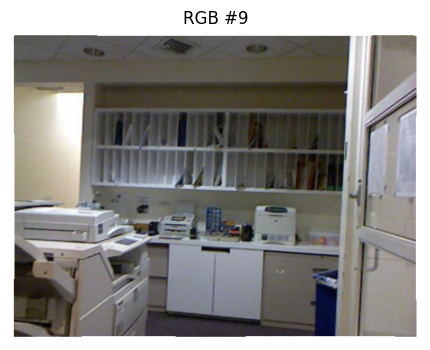

In [15]:
import numpy as np
import matplotlib.pyplot as plt

i = i+6

img_raw = images[i]  
print("img_raw.shape:", img_raw.shape) 

img = np.transpose(img_raw, (2, 1, 0)) 
print("img.shape:", img.shape)  

plt.figure(figsize=(6,4))
plt.imshow(img.astype(np.uint8))
plt.title(f"RGB #{i}")
plt.axis("off")
plt.show()


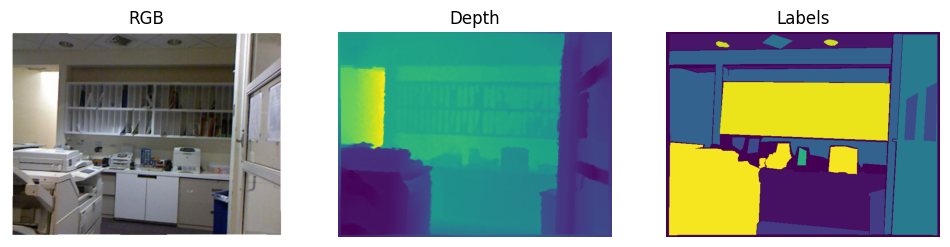

In [16]:
depth = np.transpose(depths[i], (1, 0)) 
label = np.transpose(labels[i], (1, 0)) 

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img.astype(np.uint8))
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(depth)
plt.title("Depth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(label)
plt.title("Labels")
plt.axis("off")

plt.show()


In [6]:
print("img shape:", img.shape)
print("depth shape:", depth.shape)

img shape: (480, 640, 3)
depth shape: (480, 640)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# depth = (480, 640) en MILÍMETROS
fx = 5.1885790117450188e+02
fy = 5.1946961112127485e+02
cx = 3.2558244941119034e+02
cy = 2.5373616633400465e+02

depth_m = depth.astype(np.float32)   # YA está en metros

H, W = depth_m.shape
u, v = np.meshgrid(np.arange(W), np.arange(H))

Z = depth_m
X = (u - cx) * Z / fx
Y = (v - cy) * Z / fy

points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
colors = img.reshape(-1, 3) / 255.0


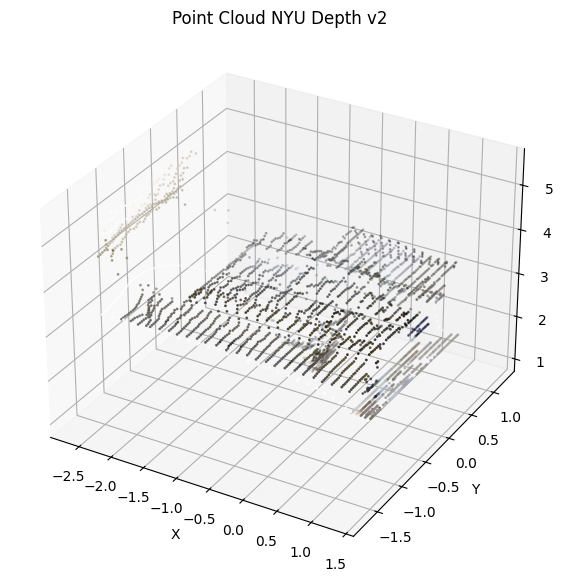

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points[::100, 0], 
           points[::100, 1], 
           points[::100, 2],
           c=colors[::100], s=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Point Cloud NYU Depth v2")

plt.show()


In [19]:
import pyvista as pv
import numpy as np

# points: (N, 3)
# colors: (N, 3)  en 0-255 o 0-1
pv.set_jupyter_backend("trame")

cloud = pv.PolyData(points)
cloud['rgb'] = (colors * 255).astype(np.uint8)

plotter = pv.Plotter()
plotter.add_points(cloud, scalars='rgb', rgb=True, point_size=3)
plotter.show(interactive=True)


Widget(value='<iframe src="http://localhost:35851/index.html?ui=P_0x70724c118200_2&reconnect=auto" class="pyvi…